In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Keep plots readable and consistent throughout the notebook
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

# Used to make any random sampling below reproducible
RANDOM_STATE = 42


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
# The raw files have no header, so we define the column names ourselves.
# Using underscores instead of hyphens makes them easier to reference later
# (df.education_num instead of df["education-num"]).
COLUMN_NAMES = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country",
    "income",
]

TRAIN_PATH = "/content/drive/MyDrive/adult_income/adult_train.csv"
TEST_PATH = "/content/drive/MyDrive/adult_income/adult_test.csv"


def load_adult_csv(path, skip_first_row=False):
    """Load one of the raw Adult CSV files into a clean DataFrame."""
    return pd.read_csv(
        path,
        # header=None,
        names=COLUMN_NAMES,
        na_values="?",          # the dataset's own marker for missing values
        skipinitialspace=True,  # strips the leading space after each comma
        skiprows=1 if skip_first_row else 0,
    )


In [16]:
train_df = load_adult_csv(TRAIN_PATH, skip_first_row=True)
test_df = load_adult_csv(TEST_PATH, skip_first_row=True)

# Keep track of which file each row came from -- useful later if we want to
# reproduce the original train/test split instead of making our own.
train_df["split"] = "train"
test_df["split"] = "test"

# Combine into a single DataFrame for cleaning and EDA
df = pd.concat([train_df, test_df], ignore_index=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Combined shape:", df.shape)
df.head()


Train shape: (32561, 16)
Test shape: (16282, 16)
Combined shape: (48843, 16)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,split
0,39,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K,train
1,50,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K,train
2,38,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K,train
3,53,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K,train
4,28,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K,train


In [17]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48843 entries, 0 to 48842
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             48843 non-null  object 
 1   workclass       46043 non-null  object 
 2   fnlwgt          48842 non-null  float64
 3   education       48842 non-null  object 
 4   education_num   48842 non-null  float64
 5   marital_status  48842 non-null  object 
 6   occupation      46033 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital_gain    48842 non-null  float64
 11  capital_loss    48842 non-null  float64
 12  hours_per_week  48842 non-null  float64
 13  native_country  47985 non-null  object 
 14  income          48842 non-null  object 
 15  split           48843 non-null  object 
dtypes: float64(5), object(11)
memory usage: 6.0+ MB


In [19]:
# How many rows and unique values does each column have?
overview = pd.DataFrame({
    "dtype": df.dtypes,
    "n_unique": df.nunique(),
    "n_missing": df.isna().sum(),
})
overview


,dtype,n_unique,n_missing
age,object,147,0
workclass,object,8,2800
fnlwgt,float64,28523,1
education,object,16,1
education_num,float64,16,1
marital_status,object,7,1
occupation,object,14,2810
relationship,object,6,1
race,object,5,1
sex,object,2,1


In [20]:
text_columns = df.select_dtypes(include="object").columns

for column in text_columns:
    df[column] = df[column].str.strip()

print("Checked text columns:", list(text_columns))


Checked text columns: ['age', 'workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income', 'split']


In [21]:
missing_counts = df.isna().sum()
missing_counts[missing_counts > 0]


,0
age,32561
workclass,2800
fnlwgt,1
education,1
education_num,1
marital_status,1
occupation,2810
relationship,1
race,1
sex,1


In [22]:
rows_before = len(df)

df = df.dropna()
df = df.reset_index(drop=True)

print(f"Dropped {rows_before - len(df)} rows with missing values.")
print("Remaining rows:", len(df))


Dropped 33783 rows with missing values.
Remaining rows: 15060


In [23]:
rows_before = len(df)

df = df.drop_duplicates()
df = df.reset_index(drop=True)

print(f"Dropped {rows_before - len(df)} duplicate rows.")
print("Remaining rows:", len(df))


Dropped 5 duplicate rows.
Remaining rows: 15055


In [24]:
df["income"] = df["income"].str.rstrip(".")

print(df["income"].value_counts())


income
<=50K    11355
>50K      3700
Name: count, dtype: int64


In [25]:
# 1 = earns more than $50K/year, 0 = earns $50K/year or less
df["income_binary"] = (df["income"] == ">50K").astype(int)

df[["income", "income_binary"]].drop_duplicates()


,income,income_binary
0,<=50K,0
2,>50K,1


EDA

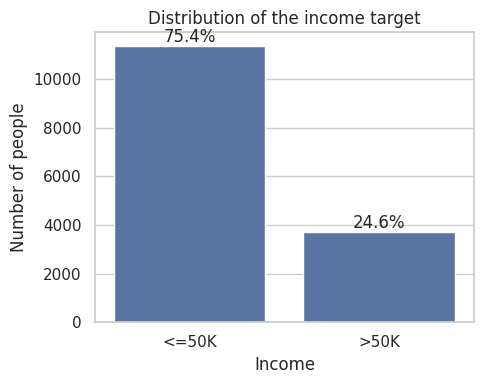

In [26]:
income_counts = df["income"].value_counts()
income_percentages = df["income"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=income_counts.index, y=income_counts.values, ax=ax)
ax.set_xlabel("Income")
ax.set_ylabel("Number of people")
ax.set_title("Distribution of the income target")

for i, pct in enumerate(income_percentages):
    ax.text(i, income_counts.iloc[i], f"{pct:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()


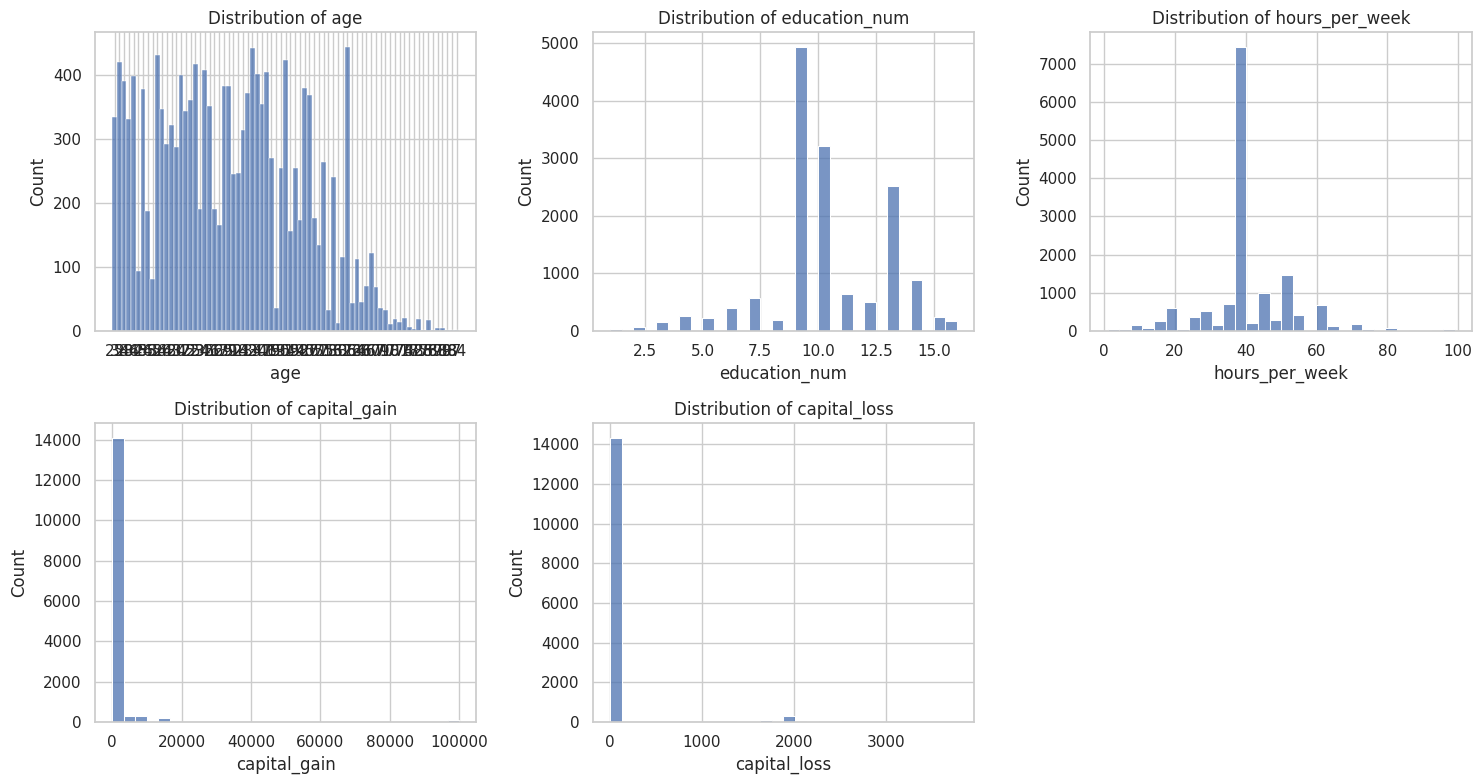

In [27]:
numeric_columns = ["age", "education_num", "hours_per_week", "capital_gain", "capital_loss"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, column in zip(axes, numeric_columns):
    sns.histplot(df[column], bins=30, ax=ax)
    ax.set_title(f"Distribution of {column}")

axes[-1].set_visible(False)

plt.tight_layout()
plt.show()


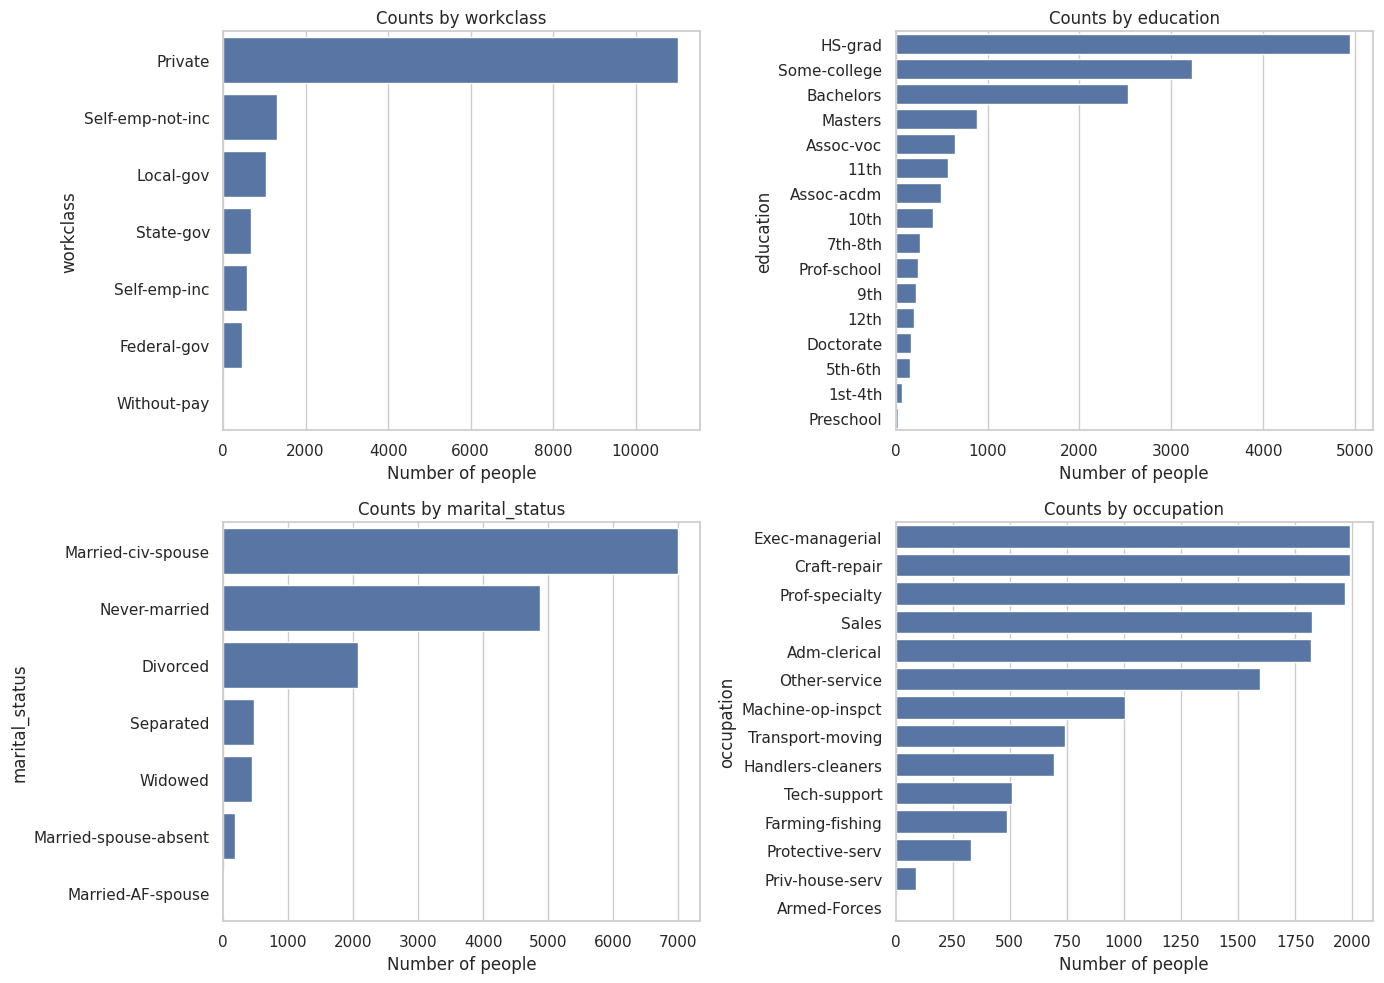

In [28]:
categorical_columns = ["workclass", "education", "marital_status", "occupation"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, column in zip(axes, categorical_columns):
    order = df[column].value_counts().index
    sns.countplot(data=df, y=column, order=order, ax=ax)
    ax.set_title(f"Counts by {column}")
    ax.set_xlabel("Number of people")

plt.tight_layout()
plt.show()


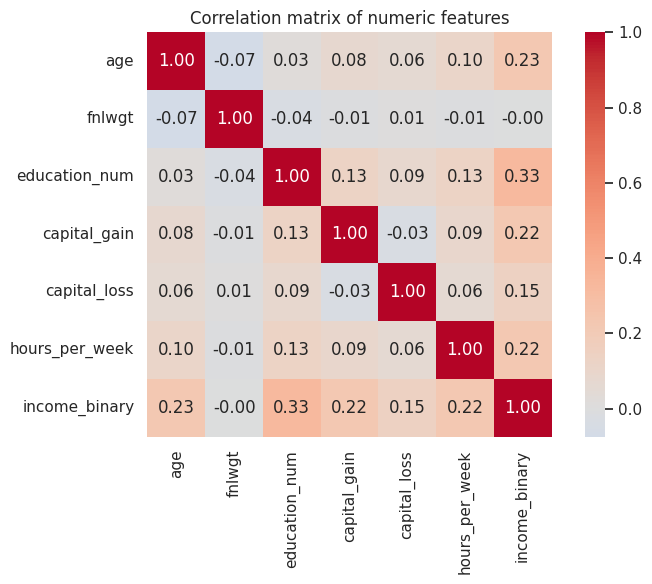

In [29]:
numeric_for_corr = [
    "age",
    "fnlwgt",
    "education_num",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "income_binary",
]

correlation_matrix = df[numeric_for_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
)
plt.title("Correlation matrix of numeric features")
plt.tight_layout()
plt.show()


In [30]:
def plot_income_counts_by_group(data, group_column, title):
    """Grouped bar chart: count of <=50K vs >50K, split by group_column."""
    plt.figure(figsize=(7, 4))
    sns.countplot(data=data, x=group_column, hue="income")
    plt.title(title)
    plt.ylabel("Number of people")
    plt.xticks(rotation=30, ha="right")
    plt.legend(title="Income")
    plt.tight_layout()
    plt.show()


def plot_earning_rate_by_group(data, group_column, title):
    """Bar chart: percentage of each group earning more than $50K."""
    earning_rate = data.groupby(group_column)["income_binary"].mean() * 100
    earning_rate = earning_rate.sort_values(ascending=False)

    plt.figure(figsize=(7, 4))
    sns.barplot(x=earning_rate.index, y=earning_rate.values)
    plt.title(title)
    plt.ylabel("% earning more than $50K")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

    return earning_rate


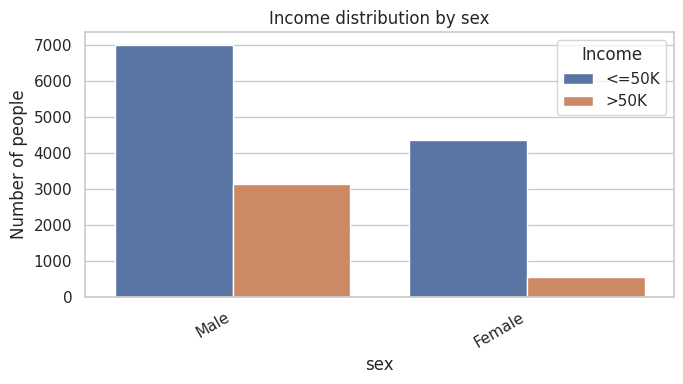

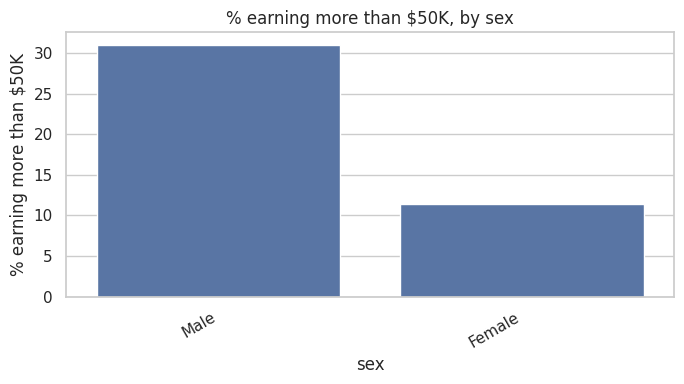

,income_binary
sex,
Male,30.986888
Female,11.339577


In [31]:
plot_income_counts_by_group(df, "sex", "Income distribution by sex")
earning_rate_by_sex = plot_earning_rate_by_group(df, "sex", "% earning more than $50K, by sex")
earning_rate_by_sex


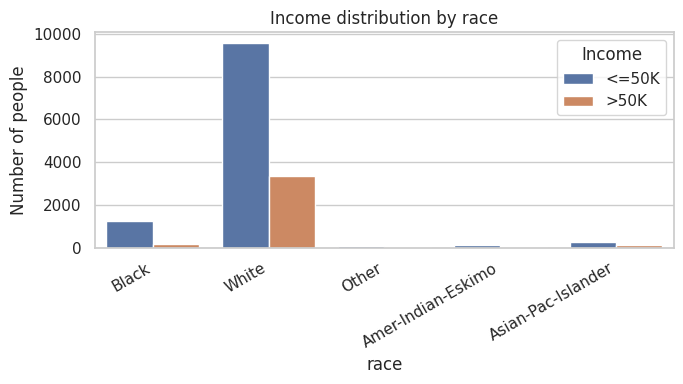

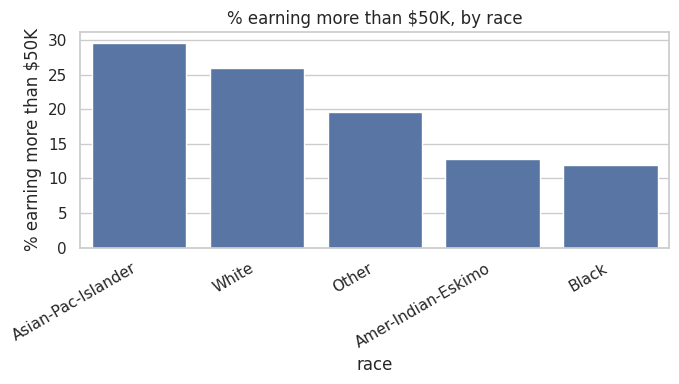

,income_binary
race,
Asian-Pac-Islander,29.656863
White,25.977632
Other,19.672131
Amer-Indian-Eskimo,12.751678
Black,11.906449


In [32]:
plot_income_counts_by_group(df, "race", "Income distribution by race")
earning_rate_by_race = plot_earning_rate_by_group(df, "race", "% earning more than $50K, by race")
earning_rate_by_race


In [33]:
df.to_csv("adult_clean.csv", index=False)
print("Saved adult_clean.csv with shape:", df.shape)


Saved adult_clean.csv with shape: (15055, 17)
